# PINNs: ODE 1D-Poisson

$$
\begin{cases}
\frac{d^2u}{dx^2} = 0 \\
u(0) = 0 \\
\dot{u}(0) = 0
\end{cases}
$$

Solution:
$$
u(x) = \frac{1}{2}x^2
$$

In [1]:
# imports
# torch
import torch
import torch.nn as nn
import torch.optim as optim

# plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")

In [2]:
# create_graph 
#   -> creates a graph with relevant derivatives for higher order computations
#   -> just as in the operations below        
# retain_graph -> retains computationl graph, defailts to create_graph
# gradients with respect to other inputs are not computed, and will not add up
# on sucessive calls.
# Why the [0] on the gradients? the return is a tuple of tensors. Each tensor is the gradient of
# one input (sequential) to one output (there can be multiple outputs, and the return onject)
# would be a multidimensional tuple
# why the grad_outputs, they are used to scale up or down the ouputted gradient.
# additional functionality, not so usefuel here. The thing that is here is essentially
# the same as having the default value for grad_outputs.

In [3]:
# Define the PINN model
class PINN(nn.Module):
    def __init__(self):
        # define arbitrary network
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 50),   # Input layer with 1 feature (domain is one dimensional)
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 1)    # Output layer for u(x), again, one dimensional.
        )

    # simple forward method
    def forward(self, x):
        return self.net(x)

    # Define the Poisson equation loss function
    def poisson_loss(self, x):

        # compute output of the net
        u = self.forward(x)

        # get derivatives of first and second order
        u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]

        # poisson residue function
        f = (u_xx - 1.0)**2  # Poisson equation: u_xx = 1
        return torch.mean(f)
    
    def boundary_condition_loss(self, x0, u0, du0):

        # estimation for u0
        u0_est = self.forward(x0)

        # residue function for u0
        residue_u0 = (u0_est - u0)**2

        # estimation for du0
        du0_est = torch.autograd.grad(u0_est, x0, grad_outputs=torch.ones_like(u0_est), create_graph=True)[0]
        
        # residue funtion for du0
        residue_du0 = (du0_est - du0)**2

        return torch.mean(residue_u0) + torch.mean(residue_du0)

In [4]:

# Training data
# domain distributed data
x = torch.rand(100, 1)  # Randomly sampled points in [0, 1]
x.requires_grad = True  # will required the gradient with respect to the input

# initial conditions restriction
x0 = torch.tensor([0.0], requires_grad=True)
u0 = torch.tensor([0.0], requires_grad=True)
du0 = torch.tensor([0.0], requires_grad=True)

# Create PINN model
model = PINN()

optimizer = optim.Adam(params=model.parameters(), lr=0.001)

# Training loop
epochs = 10000
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # Compute the loss
    # TODO: Notice, no labeled data was used here
    loss = model.poisson_loss(x) + model.boundary_condition_loss(x0, u0, du0)
    
    # Backpropagation
    loss.backward()
    optimizer.step()
    
    if epoch % 1000 == 0:
        print(f"Epoch [{epoch}/{epochs}], Loss: {loss.item()}")


Epoch [0/10000], Loss: 1.125013828277588
Epoch [1000/10000], Loss: 3.4802931622834876e-05
Epoch [2000/10000], Loss: 7.724726856395137e-06
Epoch [3000/10000], Loss: 3.641049488578574e-07
Epoch [4000/10000], Loss: 4.757417627843097e-05
Epoch [5000/10000], Loss: 1.265515402337769e-05
Epoch [6000/10000], Loss: 1.2388793102502405e-08
Epoch [7000/10000], Loss: 1.990217057823429e-08
Epoch [8000/10000], Loss: 2.6603248670653556e-07
Epoch [9000/10000], Loss: 2.379597141555223e-08


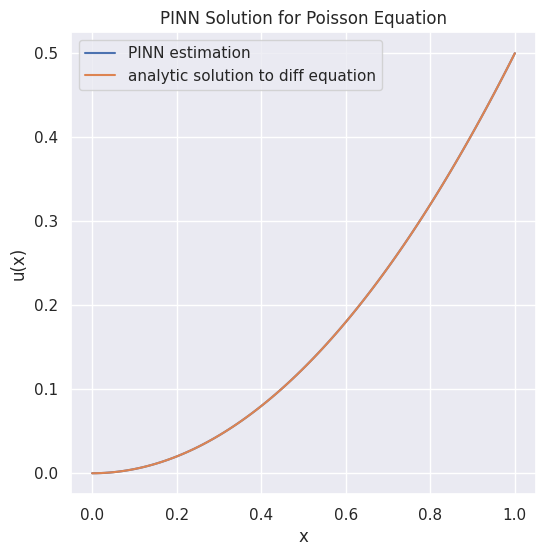

In [5]:
# Test the model

# equispace domain
x_test = torch.linspace(0, 1, 100).reshape(-1, 1)
# model estimation
u_test = model(x_test)
# analytic solution 
u_sol = (1/2)*x_test**2

# Plot the results
plt.figure(figsize=(6,6))
plt.plot(x_test.detach().numpy(), u_test.detach().numpy(), label="PINN estimation")
plt.plot(x_test.detach().numpy(), u_sol.detach().numpy(), label="analytic solution to diff equation")

plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('PINN Solution for Poisson Equation')
plt.legend()
plt.show()